<style>
/* Minimal fixes only: keep the existing site design, but make notebook code and wide tables usable. */
.highlight pre,
div.highlight,
div.input_area,
div.output_area pre {
  background: #1f1f1f !important;
  color: #f8f8f2 !important;
  border-color: #444 !important;
}
.highlight span { color: inherit !important; }
.rendered_html,
.jp-RenderedHTMLCommon {
  max-width: 100%;
  overflow-x: auto;
  -webkit-overflow-scrolling: touch;
}
.rendered_html table,
.jp-RenderedHTMLCommon table {
  display: block;
  width: max-content;
  max-width: 100%;
  min-width: 680px;
  overflow-x: auto;
  -webkit-overflow-scrolling: touch;
}
.rendered_html td,
.rendered_html th,
.jp-RenderedHTMLCommon td,
.jp-RenderedHTMLCommon th {
  white-space: nowrap;
}

.output_svg svg {
  max-width: 100%;
  height: auto;
}
.highlight .k, .highlight .kn, .highlight .kd, .highlight .kc { color: #cc7832 !important; }
.highlight .s, .highlight .s1, .highlight .s2, .highlight .sa { color: #6a8759 !important; }
.highlight .m, .highlight .mi, .highlight .mf { color: #6897bb !important; }
.highlight .c, .highlight .c1, .highlight .cm { color: #808080 !important; font-style: italic; }
.highlight .nf, .highlight .fm { color: #ffc66d !important; }
.highlight .nb, .highlight .bp { color: #a9b7c6 !important; }
.highlight .o, .highlight .ow, .highlight .p { color: #dcdcdc !important; }
.highlight .n, .highlight .nn, .highlight .nv { color: #a9b7c6 !important; }
</style>

The dataset behind this article was generated from a resumable local SQLite checkpoint of the public 2026 CrossFit Open leaderboard API. I exported the normalized tables into a compact GitHub Release asset, excluded raw API response bodies, converted height and weight to metric units, and use the release download below as the source for the rest of the analysis.

The practical question I care about is percentile cutoffs: given a sex and age-group division, what rank and score did an athlete need for the 50th, 75th, 90th, and 95th percentiles?


## Load the release asset

The tarball lives as a GitHub Release asset. The notebook downloads it, verifies the SHA-256, and loads the CSVs from the extracted archive.

Release asset: <https://github.com/leblancfg/leblancfg.github.io/releases/download/crossfit-open-2026-compact-v1/crossfit-open-2026-compact-v1.tar.gz>. Checksum file: <https://github.com/leblancfg/leblancfg.github.io/releases/download/crossfit-open-2026-compact-v1/SHA256SUMS>.


In [1]:
from __future__ import annotations

import csv
import hashlib
import json
import tarfile
import urllib.request
from collections import defaultdict
from pathlib import Path

from IPython.display import Markdown, SVG, display

RELEASE_TAG = "crossfit-open-2026-compact-v1"
ASSET_NAME = "crossfit-open-2026-compact-v1.tar.gz"
ASSET_URL = f"https://github.com/leblancfg/leblancfg.github.io/releases/download/{RELEASE_TAG}/{ASSET_NAME}"
EXPECTED_SHA256 = "742f89eed0fa381570111b8b0fb82d97a44d40d13c14a3fcf6bfcd848a6751dd"
CACHE_DIR = Path.home() / ".cache" / "leblancfg" / RELEASE_TAG
ARCHIVE_PATH = CACHE_DIR / ASSET_NAME
EXTRACTED_DIR = CACHE_DIR / "crossfit-open-2026-compact-v1"

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def safe_extract(tar: tarfile.TarFile, destination: Path) -> None:
    destination = destination.resolve()
    for member in tar.getmembers():
        target = (destination / member.name).resolve()
        if destination not in target.parents and target != destination:
            raise RuntimeError(f"unsafe tar member: {member.name}")
    tar.extractall(destination)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
if not ARCHIVE_PATH.exists():
    urllib.request.urlretrieve(ASSET_URL, ARCHIVE_PATH)

actual_sha256 = sha256_file(ARCHIVE_PATH)
assert actual_sha256 == EXPECTED_SHA256, actual_sha256

if not (EXTRACTED_DIR / "metadata.json").exists():
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        safe_extract(tar, CACHE_DIR)

display(Markdown(f"Downloaded `{ASSET_NAME}` and verified SHA-256 `{actual_sha256}`."))


Downloaded `crossfit-open-2026-compact-v1.tar.gz` and verified SHA-256 `742f89eed0fa381570111b8b0fb82d97a44d40d13c14a3fcf6bfcd848a6751dd`.

In [2]:
def load_csv(name: str) -> list[dict[str, str]]:
    with (EXTRACTED_DIR / name).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

def int_or_none(value: str | None) -> int | None:
    return int(value) if value not in (None, "") else None

def float_or_none(value: str | None) -> float | None:
    return float(value) if value not in (None, "") else None

def fmt_int(value: int | str | None) -> str:
    if value in (None, ""):
        return ""
    return f"{int(value):,}"

def markdown_table(headers: list[str], rows: list[list[object]]) -> Markdown:
    def cell(value: object) -> str:
        return str(value).replace("|", "\|")
    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for row in rows:
        lines.append("| " + " | ".join(cell(value) for value in row) + " |")
    return Markdown("\n".join(lines))

metadata = json.loads((EXTRACTED_DIR / "metadata.json").read_text(encoding="utf-8"))
divisions = load_csv("divisions.csv")
athletes = load_csv("athletes.csv")
entries = load_csv("leaderboard_entries.csv")
scores = load_csv("workout_scores.csv")
benchmarks = load_csv("sample_benchmark_stats.csv")

def svg_escape(value: object) -> str:
    return str(value).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

def bar_svg(title: str, rows: list[dict[str, object]], *, note: str = "", left: int = 190, width: int = 940) -> str:
    right, top, bottom, bar_h, gap = 125, 58, 34, 22, 8
    max_value = max(float(row["value"]) for row in rows) or 1
    plot_w = width - left - right
    height = top + bottom + len(rows) * (bar_h + gap) - gap
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}" role="img" aria-label="{svg_escape(title)}">']
    parts.append('<style>.cfchart-title{font:600 18px system-ui,-apple-system,Segoe UI,sans-serif;fill:#dcdcdc}.cfchart-label{font:12px system-ui,-apple-system,Segoe UI,sans-serif;fill:#a9b7c6}.cfchart-value{font:12px system-ui,-apple-system,Segoe UI,sans-serif;fill:#dcdcdc}.cfchart-note{font:12px system-ui,-apple-system,Segoe UI,sans-serif;fill:#808080}.cfchart-grid{stroke:#3c3f41;stroke-width:1}.cfchart-axis{stroke:#606366;stroke-width:1}</style>')
    parts.append(f'<rect width="{width}" height="{height}" fill="#2b2b2b" rx="6"/><text class="cfchart-title" x="18" y="30">{svg_escape(title)}</text>')
    if note:
        parts.append(f'<text class="cfchart-note" x="18" y="49">{svg_escape(note)}</text>')
    for tick in (0.25, 0.5, 0.75, 1.0):
        x = left + plot_w * tick
        parts.append(f'<line class="cfchart-grid" x1="{x:.1f}" y1="{top - 10}" x2="{x:.1f}" y2="{height - bottom + 4}"/>')
    parts.append(f'<line class="cfchart-axis" x1="{left}" y1="{top - 10}" x2="{left}" y2="{height - bottom + 4}"/>')
    for index, row in enumerate(rows):
        y = top + index * (bar_h + gap)
        bar_w = max(2, plot_w * (float(row["value"]) / max_value))
        parts.append(f'<text class="cfchart-label" x="18" y="{y + 15}">{svg_escape(row["label"])}</text>')
        parts.append(f'<rect x="{left}" y="{y}" width="{bar_w:.1f}" height="{bar_h}" rx="3" fill="{row.get("color", "#6a8759")}"/>')
        parts.append(f'<text class="cfchart-value" x="{left + bar_w + 8:.1f}" y="{y + 15}">{svg_escape(row["display"])}</text>')
    return "".join(parts + ["</svg>"])

def small_multiples_svg(title: str, panels: list[dict[str, object]]) -> str:
    width, panel_w, left, right, bar_h, gap = 980, 455, 145, 80, 18, 7
    panel_h, panel_gap_y, top_title = 181, 26, 48
    height = top_title + 2 * panel_h + panel_gap_y + 52
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}" role="img" aria-label="{svg_escape(title)}">']
    parts.append('<style>.cfchart-title{font:600 18px system-ui,-apple-system,Segoe UI,sans-serif;fill:#dcdcdc}.cfchart-panel{font:600 14px system-ui,-apple-system,Segoe UI,sans-serif;fill:#ffc66d}.cfchart-label{font:11px system-ui,-apple-system,Segoe UI,sans-serif;fill:#a9b7c6}.cfchart-value{font:11px system-ui,-apple-system,Segoe UI,sans-serif;fill:#dcdcdc}.cfchart-grid{stroke:#3c3f41;stroke-width:1}.cfchart-axis{stroke:#606366;stroke-width:1}</style>')
    parts.append(f'<rect width="{width}" height="{height}" fill="#2b2b2b" rx="6"/><text class="cfchart-title" x="18" y="30">{svg_escape(title)}</text>')
    for panel_index, panel in enumerate(panels):
        col, row_num = panel_index % 2, panel_index // 2
        x0, y0 = 18 + col * (panel_w + 28), top_title + row_num * (panel_h + panel_gap_y)
        plot_w = panel_w - left - right
        rows = panel["rows"]
        max_value = max(float(row["value"]) for row in rows) or 1
        parts.append(f'<text class="cfchart-panel" x="{x0}" y="{y0 + 16}">{svg_escape(panel["title"])}</text>')
        parts.append(f'<line class="cfchart-axis" x1="{x0 + left}" y1="{y0 + 26}" x2="{x0 + left}" y2="{y0 + panel_h - 12}"/>')
        for index, item in enumerate(rows):
            y = y0 + 26 + index * (bar_h + gap)
            bar_w = max(2, plot_w * (float(item["value"]) / max_value))
            parts.append(f'<text class="cfchart-label" x="{x0}" y="{y + 13}">{svg_escape(item["label"])}</text>')
            parts.append(f'<rect x="{x0 + left}" y="{y}" width="{bar_w:.1f}" height="{bar_h}" rx="3" fill="{item.get("color", "#6a8759")}"/>')
            parts.append(f'<text class="cfchart-value" x="{x0 + left + bar_w + 6:.1f}" y="{y + 13}">{svg_escape(item["display"])}</text>')
    return "".join(parts + ["</svg>"])

def display_svg(svg: str) -> None:
    display(SVG(svg))


## Reproduce the release counts

The release contains the complete normalized leaderboard crawl for every 2026 Open division. The SQLite checkpoint had raw fetch bodies too; those are deliberately absent here.


In [3]:
actual_counts = {
    "divisions.csv": len(divisions),
    "athletes.csv": len(athletes),
    "leaderboard_entries.csv": len(entries),
    "workout_scores.csv": len(scores),
    "sample_benchmark_stats.csv": len(benchmarks),
}
count_rows = []
for filename, expected in metadata["exported_row_counts"].items():
    actual = actual_counts[filename]
    count_rows.append([filename, fmt_int(expected), fmt_int(actual), "yes" if expected == actual else "no"])
display(markdown_table(["File", "Metadata rows", "Loaded rows", "Matches"], count_rows))


| File | Metadata rows | Loaded rows | Matches |
| --- | --- | --- | --- |
| divisions.csv | 23 | 23 | yes |
| athletes.csv | 254,531 | 254,531 | yes |
| leaderboard_entries.csv | 388,423 | 388,423 | yes |
| workout_scores.csv | 1,165,269 | 1,165,269 | yes |
| sample_benchmark_stats.csv | 165 | 165 | yes |

## Percentile cutoffs by sex and age-group division

Percentiles here are rank-derived. For a division with `N` athletes, the percentile for rank `r` is `100 * (1 - ((r - 1) / (N - 1)))`. The cutoff below is the worst rank still at or above the requested percentile. Because ties can share a rank, `athletes_at_or_above` can differ slightly from the rank number.


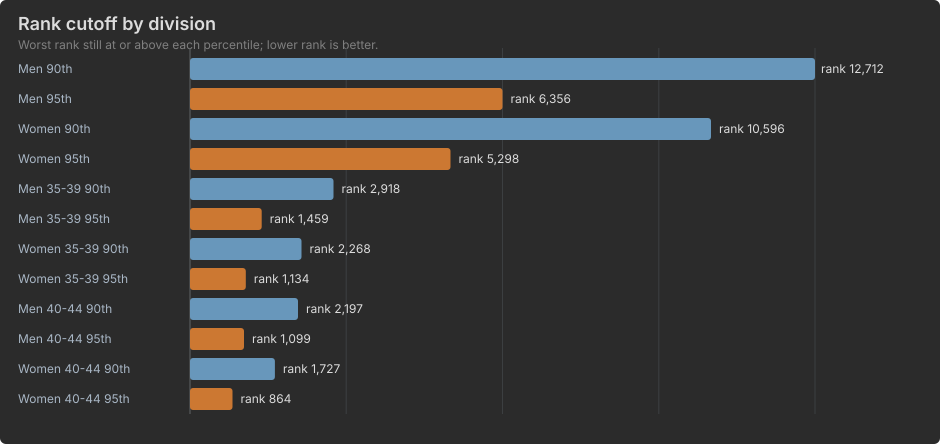

In [4]:
division_by_id = {row["division_id"]: row for row in divisions if row["category"] != "team"}
entries_by_division: dict[str, list[dict[str, str]]] = defaultdict(list)
for row in entries:
    if row["division_id"] in division_by_id:
        entries_by_division[row["division_id"]].append(row)

cutoffs = []
for division_id, division_entries in entries_by_division.items():
    division = division_by_id[division_id]
    for percentile in (50, 75, 90, 95):
        eligible = [
            row
            for row in division_entries
            if float_or_none(row["performance_percentile"]) is not None
            and float(row["performance_percentile"]) >= percentile
        ]
        cutoff_rank = max(int(row["overall_rank"]) for row in eligible if row["overall_rank"])
        cutoff_row = sorted(
            (row for row in division_entries if int_or_none(row["overall_rank"]) == cutoff_rank),
            key=lambda row: int(row["athlete_id"]) if row["athlete_id"].isdigit() else row["athlete_id"],
        )[0]
        cutoffs.append({
            "sex": division["sex"],
            "division_name": division["division_name"],
            "percentile": percentile,
            "division_size": len(division_entries),
            "rank_cutoff": cutoff_rank,
            "athletes_at_or_above": len(eligible),
            "athlete_id": cutoff_row["athlete_id"],
            "overall_score": cutoff_row["overall_score"],
            "division_id": division_id,
        })

chart_colors = {90: "#6897bb", 95: "#cc7832"}
chart_rows = []
for division_name in ("Men", "Women", "Men 35-39", "Women 35-39", "Men 40-44", "Women 40-44"):
    for percentile in (90, 95):
        row = next(item for item in cutoffs if item["division_name"] == division_name and item["percentile"] == percentile)
        chart_rows.append({
            "label": f"{division_name} {percentile}th",
            "value": row["rank_cutoff"],
            "display": f"rank {fmt_int(row['rank_cutoff'])}",
            "color": chart_colors[percentile],
        })

display_svg(bar_svg("Rank cutoff by division", chart_rows, note="Worst rank still at or above each percentile; lower rank is better."))


The rank cutoffs scale with field size, which is exactly what a rank-derived percentile should do. The more useful training view is the boundary row itself: the overall score at that rank, and the three workout scores that produced it.


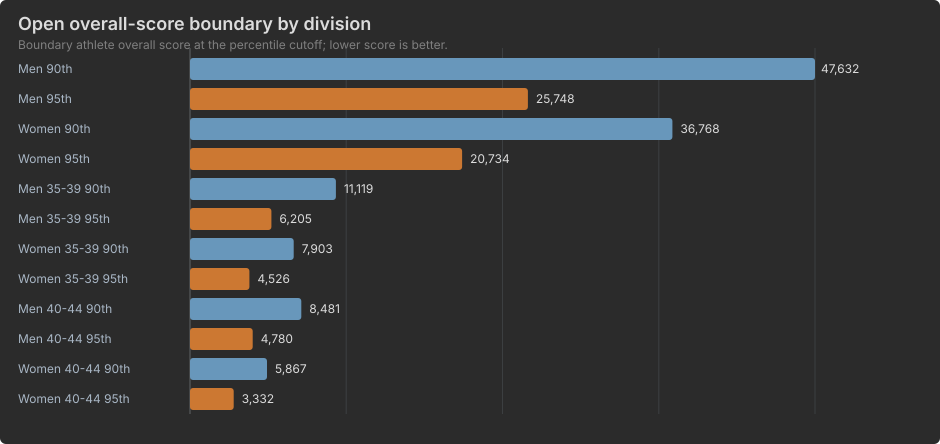

In [5]:
score_by_entry: dict[tuple[str, str], dict[int, str]] = defaultdict(dict)
for row in scores:
    score_by_entry[(row["division_id"], row["athlete_id"])][int(row["workout_ordinal"])] = row["score_display"]

focus_divisions = {"Men", "Women", "Men 35-39", "Women 35-39", "Men 40-44", "Women 40-44"}

chart_colors = {90: "#6897bb", 95: "#cc7832"}
chart_rows = []
for division_name in ("Men", "Women", "Men 35-39", "Women 35-39", "Men 40-44", "Women 40-44"):
    for percentile in (90, 95):
        row = next(item for item in cutoffs if item["division_name"] == division_name and item["percentile"] == percentile)
        chart_rows.append({
            "label": f"{division_name} {percentile}th",
            "value": int(row["overall_score"]),
            "display": fmt_int(row["overall_score"]),
            "color": chart_colors[percentile],
        })

display_svg(bar_svg("Open overall-score boundary by division", chart_rows, note="Boundary athlete overall score at the percentile cutoff; lower score is better."))


For the target division I care about most, Men 35-39, 90th percentile in the 2026 Open meant rank 2,918 out of 29,171, with a boundary overall score of 11,119. Moving from 90th to 95th percentile cut the allowed rank roughly in half, to 1,459, and the boundary overall score dropped to 6,205.

That gives a reproducible cutoff table: pick the sex and age group, then read off the leaderboard target.


## Benchmark profile caveats

The leaderboard tables above answer the rank question well: for a given division and percentile, they identify the boundary athlete and the Open workout scores at that boundary. Benchmark fields need more care. They come from public CrossFit athlete profiles, are self-reported, and usually represent lifetime PR values.

The compact release includes the full leaderboard and workout-score crawl. Its `sample_benchmark_stats.csv` file was only a parser proof sample: 165 benchmark rows from 17 elite men. The profile benchmark charts below use a new targeted cutoff-window crawl, published as a separate CSV, so the article no longer relies on that proof sample.


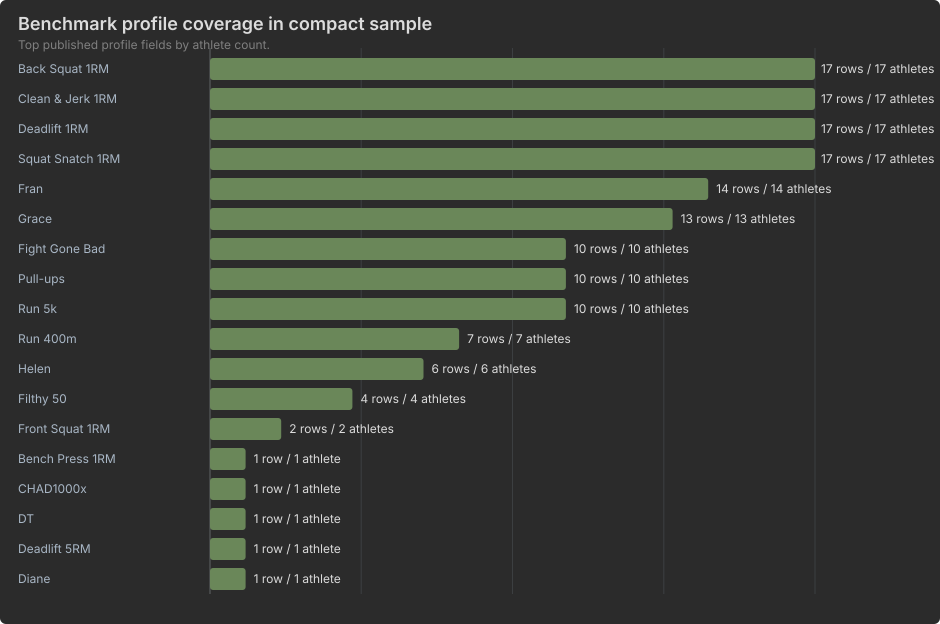

In [6]:
from statistics import median

def seconds_to_mmss(seconds: float | int | None) -> str:
    if seconds in (None, ""):
        return ""
    seconds = int(round(float(seconds)))
    return f"{seconds // 60}:{seconds % 60:02d}"

def kg_to_lb(kg: float | int | None) -> float | None:
    return None if kg is None else float(kg) / 0.45359237

def safe_float(value: str | None) -> float | None:
    return float(value) if value not in (None, "") else None

athlete_by_id = {row["athlete_id"]: row for row in athletes}
benchmark_by_athlete: dict[str, dict[str, dict[str, str]]] = defaultdict(dict)
for row in benchmarks:
    benchmark_by_athlete[row["athlete_id"]][row["stat_name"]] = row

coverage_rows = []
for stat_name in sorted({row["stat_name"] for row in benchmarks}):
    rows = [row for row in benchmarks if row["stat_name"] == stat_name]
    coverage_rows.append([stat_name, len(rows), len({row["athlete_id"] for row in rows})])

chart_rows = []
for stat_name, row_count, athlete_count in sorted(coverage_rows, key=lambda row: (-row[2], row[0]))[:18]:
    row_word = "row" if row_count == 1 else "rows"
    athlete_word = "athlete" if athlete_count == 1 else "athletes"
    chart_rows.append({
        "label": stat_name,
        "value": athlete_count,
        "display": f"{row_count} {row_word} / {athlete_count} {athlete_word}",
        "color": "#6a8759",
    })

display_svg(bar_svg("Benchmark profile coverage in compact sample", chart_rows, note="Top published profile fields by athlete count.", left=210))


## Equivalence functions for the four benchmark families

The leaderboard and workout-score release is complete. Public profile benchmarks need a separate pass: CrossFit stores them on athlete profile pages, and many athletes leave them blank. I added a targeted profile-benchmark extension using public profiles near the cutoff ranks.

Targeted profile CSV: `/data/crossfit_open_2026_targeted_benchmark_stats.csv`. It covers athletes within ±15 ranks of the 90th, 95th, and 99th percentile cutoffs for Men, Women, Men 35-39, Women 35-39, Men 40-44, and Women 40-44. Two profile URLs returned 404. Blank profile benchmark fields stay missing.

Counts in the charts are profile counts for that metric inside the cutoff window. They are not percentile values.

**Steady-state cardio: FTP-equivalent.** CrossFit profiles usually don't publish cycling FTP. The closest public profile tests in this crawl are `Run 5k` and, much more rarely, `Row 5K`. For a 5k run, estimate an FTP-like cycling value in W/kg by converting 5k speed into a critical-speed proxy, then applying an economy/efficiency bridge:

```text
running_speed_mps = 5000 / run_5k_seconds
critical_speed_mps = 0.92 * running_speed_mps
ftp_equivalent_wkg = critical_speed_mps * 4.184 * 0.23
```

The `4.184` term is the common running-energy-cost approximation of about 1 kcal/kg/km. The `0.23` term treats cycling FTP as external mechanical power at about 23% gross efficiency. This produces a steady-state engine equivalence from a published running test.

**High-energy cardio: 400m time.** Use `Run 400m` directly as a high-power cardio benchmark. Lower time is better:

```text
run_400_seconds = profile["Run 400m"].time_seconds
```

**Slow strength: CrossFit Total.** The closest slow-strength abstraction is CrossFit Total: back squat + shoulder press + deadlift. If a profile publishes all three components, reconstruct it directly:

```text
crossfit_total_kg = back_squat_1rm_kg + shoulder_press_1rm_kg + deadlift_1rm_kg
```

If one component is missing, leave the total missing.

**Fast strength: 1RM clean & jerk.** Use `Clean & Jerk 1RM` directly, shown in kilograms. This is the cleanest fast-strength proxy in the published profile fields because it combines speed, coordination, and maximal loading.


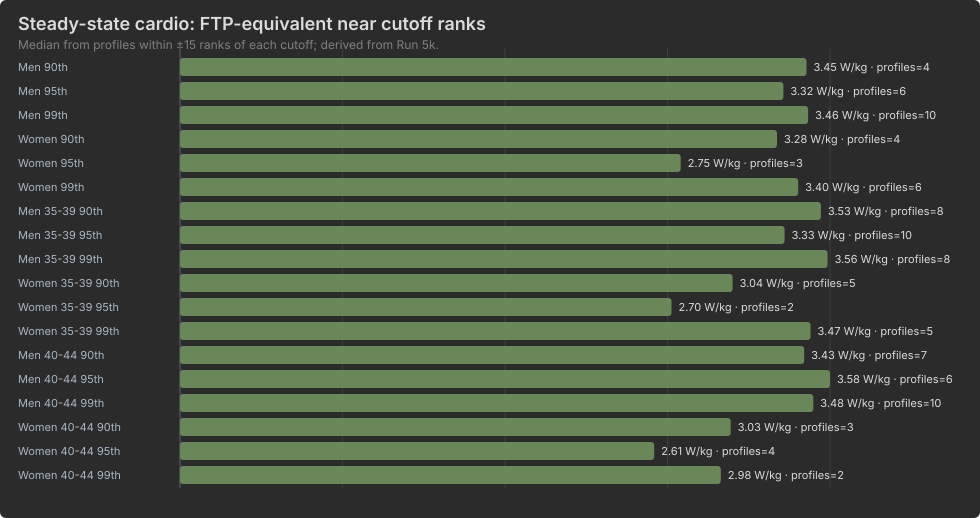

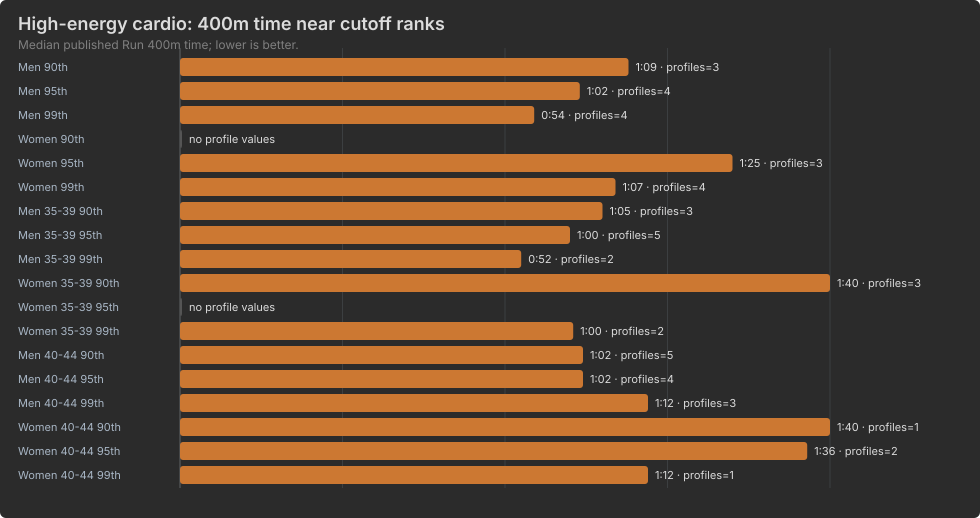

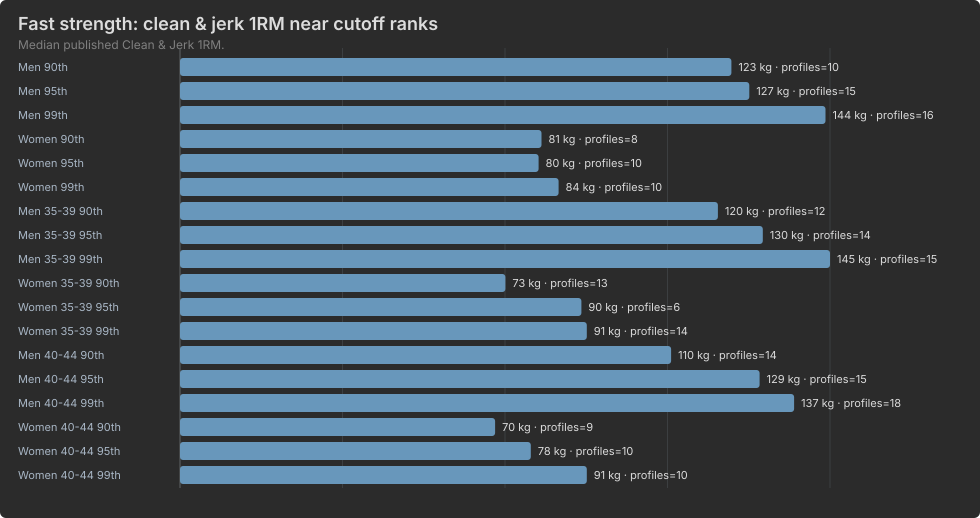

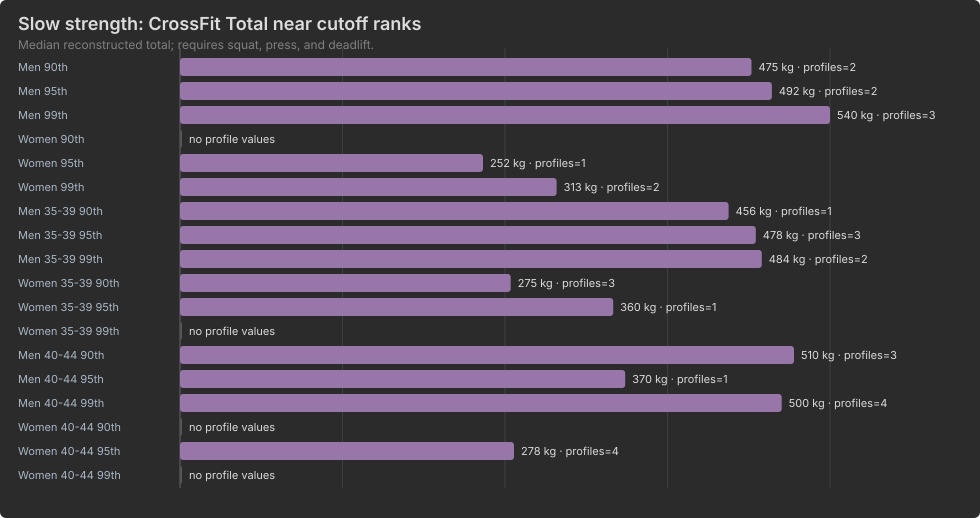

In [7]:
targeted_benchmark_path = Path("content/data/crossfit_open_2026_targeted_benchmark_stats.csv")
if not targeted_benchmark_path.exists():
    targeted_benchmark_path = Path("data/crossfit_open_2026_targeted_benchmark_stats.csv")

with targeted_benchmark_path.open(newline="", encoding="utf-8") as handle:
    targeted_benchmarks = list(csv.DictReader(handle))

def run_5k_to_ftp_equivalent_wkg(seconds: float) -> float:
    running_speed_mps = 5000 / seconds
    critical_speed_mps = 0.92 * running_speed_mps
    return critical_speed_mps * 4.184 * 0.23

def benchmark_value_kg(stats: dict[str, dict[str, str]], name: str) -> float | None:
    row = stats.get(name)
    return safe_float(row.get("value_kg")) if row else None

def benchmark_time_seconds(stats: dict[str, dict[str, str]], name: str) -> float | None:
    row = stats.get(name)
    return safe_float(row.get("time_seconds")) if row else None

def crossfit_total_kg(stats: dict[str, dict[str, str]]) -> float | None:
    parts = [benchmark_value_kg(stats, name) for name in ("Back Squat 1RM", "Shoulder Press 1RM", "Deadlift 1RM")]
    return sum(parts) if all(part is not None for part in parts) else None

def targeted_stats_by_athlete() -> dict[tuple[str, int, str], dict[str, dict[str, str]]]:
    grouped: dict[tuple[str, int, str], dict[str, dict[str, str]]] = defaultdict(dict)
    for row in targeted_benchmarks:
        key = (row["division_name"], int(row["target_percentile"]), row["athlete_id"])
        grouped[key][row["stat_name"]] = row
    return grouped

cohort_stats = targeted_stats_by_athlete()
cohort_order = [
    (division_name, percentile)
    for division_name in ("Men", "Women", "Men 35-39", "Women 35-39", "Men 40-44", "Women 40-44")
    for percentile in (90, 95, 99)
]

def cohort_values(division_name: str, percentile: int, metric: str) -> list[float]:
    values = []
    for (cohort_division, cohort_percentile, _athlete_id), stats in cohort_stats.items():
        if cohort_division != division_name or cohort_percentile != percentile:
            continue
        if metric == "ftp_equiv_wkg":
            run5k = benchmark_time_seconds(stats, "Run 5k")
            if run5k:
                values.append(run_5k_to_ftp_equivalent_wkg(run5k))
        elif metric == "run_400_seconds":
            run400 = benchmark_time_seconds(stats, "Run 400m")
            if run400:
                values.append(run400)
        elif metric == "clean_jerk_kg":
            clean_jerk = benchmark_value_kg(stats, "Clean & Jerk 1RM")
            if clean_jerk:
                values.append(clean_jerk)
        elif metric == "crossfit_total_kg":
            total = crossfit_total_kg(stats)
            if total:
                values.append(total)
    return values

def metric_rows(metric: str, formatter, color: str) -> list[dict[str, object]]:
    rows = []
    for division_name, percentile in cohort_order:
        values = cohort_values(division_name, percentile, metric)
        if values:
            value = median(values)
            display = f"{formatter(value)} · profiles={len(values)}"
        else:
            value = 0
            display = "no profile values"
        rows.append({"label": f"{division_name} {percentile}th", "value": value, "display": display, "color": color})
    return rows

for title, metric, formatter, color, note in [
    ("Steady-state cardio: FTP-equivalent near cutoff ranks", "ftp_equiv_wkg", lambda value: f"{value:.2f} W/kg", "#6a8759", "Median from profiles within ±15 ranks of each cutoff; derived from Run 5k."),
    ("High-energy cardio: 400m time near cutoff ranks", "run_400_seconds", seconds_to_mmss, "#cc7832", "Median published Run 400m time; lower is better."),
    ("Fast strength: clean & jerk 1RM near cutoff ranks", "clean_jerk_kg", lambda value: f"{value:.0f} kg", "#6897bb", "Median published Clean & Jerk 1RM."),
    ("Slow strength: CrossFit Total near cutoff ranks", "crossfit_total_kg", lambda value: f"{value:.0f} kg", "#9876aa", "Median reconstructed total; requires squat, press, and deadlift."),
]:
    display_svg(bar_svg(title, metric_rows(metric, formatter, color), note=note, left=180, width=980))


This cutoff-neighbourhood extension covers the divisions and percentiles shown above. The article's benchmark charts now use those public profiles instead of the old 17-athlete proof sample.

A future full benchmark release should crawl every public athlete profile from `athletes.csv`, keep missing profile fields explicit, and publish benchmark coverage by division so users can judge self-reporting bias.
